# Stage 2 - Machine Learning & Classification
## Behavioural Finance Analyser

**Goal:** Predict the spending category of a transaction based on behavioural features.

**Model Type:** Multi-class Classification  
**Target Variable:** `category`  
**Dataset:** Cleaned transaction data from Stage 1

---

Import necessary libraries

In [40]:
import pandas as pd
import numpy as np
import datetime as dt
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
import matplotlib.pyplot as plt

#ml models
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report,confusion_matrix, ConfusionMatrixDisplay

In [41]:
fin_df = pd.read_csv(r'D:\Workspace\Projects\AI_ML\behavioural-finance-analyser\data\processed\cleaned_fin_df.csv')
fin_df.head()

,Date,Time,Category,Sub category,flow,transaction_amount
0,2021-01-01,21:45:00,Allowance,From dad,Income,8000.0
1,2021-01-01,21:46:00,Food,Snacks,Expense,85.0
2,2021-01-03,18:21:00,Other,From dad,Income,500.0
3,2021-01-03,18:22:00,Household,Stuffs,Expense,6667.0
4,2021-01-03,18:56:00,Transportation,Metro,Expense,30.0


In [42]:
fin_df.dtypes

Date                      str
Time                      str
Category                  str
Sub category              str
flow                      str
transaction_amount    float64
dtype: object

In [43]:
#convert date, time and transaction_amount to appropriate datatypes.

fin_df['Date'] = pd.to_datetime(fin_df['Date'])
fin_df['Time'] = pd.to_datetime(fin_df['Time'], format='%H:%M:%S').dt.time
fin_df['transaction_amount'] = fin_df['transaction_amount'].astype(int)

fin_df.dtypes

Date                  datetime64[us]
Time                          object
Category                         str
Sub category                     str
flow                             str
transaction_amount             int64
dtype: object

In [44]:

fin_df['month'] = fin_df['Date'].dt.month
fin_df['day'] = fin_df['Date'].dt.day

fin_df['day_of_week'] = fin_df['Date'].dt.weekday  # 0=Mon, 6=Sun

fin_df['is_weekend'] = (
    fin_df['Date'].dt.dayofweek >= 5
).astype(int)

fin_df.head()

,Date,Time,Category,Sub category,flow,transaction_amount,month,day,day_of_week,is_weekend
0,2021-01-01,21:45:00,Allowance,From dad,Income,8000,1,1,4,0
1,2021-01-01,21:46:00,Food,Snacks,Expense,85,1,1,4,0
2,2021-01-03,18:21:00,Other,From dad,Income,500,1,3,6,1
3,2021-01-03,18:22:00,Household,Stuffs,Expense,6667,1,3,6,1
4,2021-01-03,18:56:00,Transportation,Metro,Expense,30,1,3,6,1


In [45]:
fin_df.isnull().sum()

Date                  0
Time                  0
Category              0
Sub category          0
flow                  0
transaction_amount    0
month                 0
day                   0
day_of_week           0
is_weekend            0
dtype: int64

## 2. Encoding Categorical Variables
Converting text columns into numerical form so the model can process them.

In [46]:
fin_df['month'] = fin_df['Date'].dt.month
fin_df['day'] = fin_df['Date'].dt.day

fin_df['day_of_week'] = fin_df['Date'].dt.weekday  # 0=Mon, 6=Sun

fin_df['is_weekend'] = (fin_df['day_of_week'] >= 5).astype(int)


le = LabelEncoder()

fin_df['category_encoded'] = le.fit_transform(fin_df['Category'])
fin_df['flow'] = le.fit_transform(fin_df['flow'])


fin_df = pd.get_dummies(
    fin_df,
    columns=['day_of_week'],
    dtype=int
)

time_dt = pd.to_datetime(fin_df['Time'].astype(str))

fin_df['hour'] = time_dt.dt.hour
fin_df['minute'] = time_dt.dt.minute

fin_df.head()

C:\Users\urjad\AppData\Local\Temp\ipykernel_10476\2981486616.py:21: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  time_dt = pd.to_datetime(fin_df['Time'].astype(str))


,Date,Time,Category,Sub category,flow,transaction_amount,month,day,is_weekend,category_encoded,day_of_week_0,day_of_week_1,day_of_week_2,day_of_week_3,day_of_week_4,day_of_week_5,day_of_week_6,hour,minute
0,2021-01-01,21:45:00,Allowance,From dad,1,8000,1,1,0,0,0,0,0,0,1,0,0,21,45
1,2021-01-01,21:46:00,Food,Snacks,0,85,1,1,0,3,0,0,0,0,1,0,0,21,46
2,2021-01-03,18:21:00,Other,From dad,1,500,1,3,1,5,0,0,0,0,0,0,1,18,21
3,2021-01-03,18:22:00,Household,Stuffs,0,6667,1,3,1,4,0,0,0,0,0,0,1,18,22
4,2021-01-03,18:56:00,Transportation,Metro,0,30,1,3,1,7,0,0,0,0,0,0,1,18,56


In [47]:
fin_df.shape

(225, 19)

In [48]:
fin_df.to_csv('../data/processed/fin_df_encoded.csv')
fin_df.columns

Index(['Date', 'Time', 'Category', 'Sub category', 'flow',
       'transaction_amount', 'month', 'day', 'is_weekend', 'category_encoded',
       'day_of_week_0', 'day_of_week_1', 'day_of_week_2', 'day_of_week_3',
       'day_of_week_4', 'day_of_week_5', 'day_of_week_6', 'hour', 'minute'],
      dtype='str')

## 3. Feature Selection
Defining X (input features) and y (target variable)

In [49]:
y = fin_df['category_encoded']
X = fin_df.drop(columns = ['category_encoded', 'Category'])

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nFeatures:", X.columns.tolist())

X shape: (225, 17)
y shape: (225,)

Features: ['Date', 'Time', 'Sub category', 'flow', 'transaction_amount', 'month', 'day', 'is_weekend', 'day_of_week_0', 'day_of_week_1', 'day_of_week_2', 'day_of_week_3', 'day_of_week_4', 'day_of_week_5', 'day_of_week_6', 'hour', 'minute']


In [50]:
fin_df_ml = fin_df.drop(
    columns=[
        'Date',
        'Time',
        'Category',
        'Sub category'
    ]
)

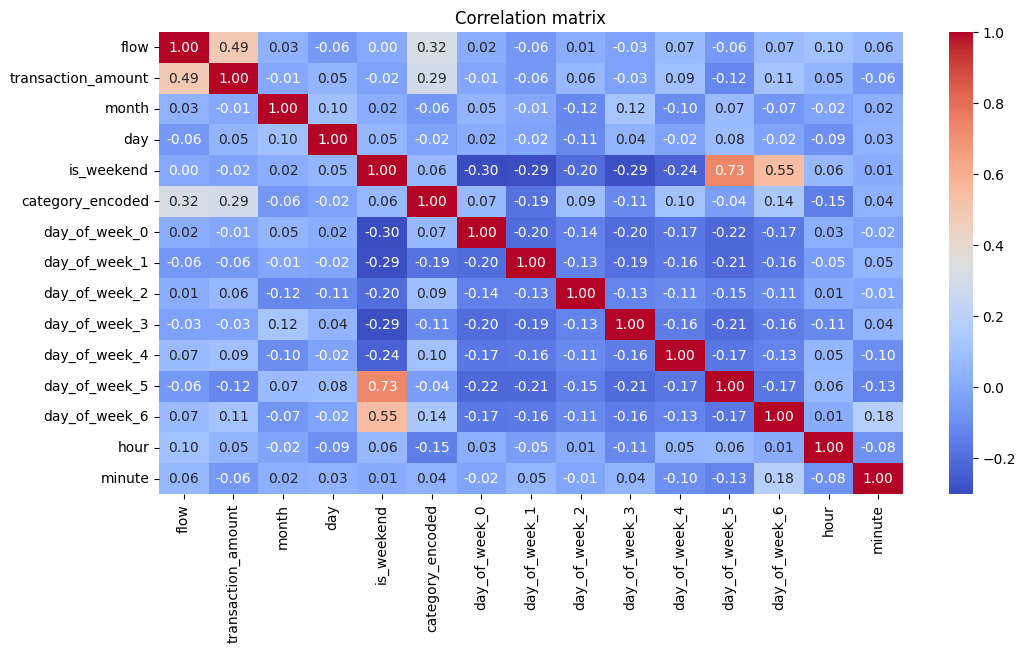

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

corr = fin_df_ml.corr(numeric_only=True)
plt.figure(figsize = (12,6))
sns.heatmap(corr,annot = True, fmt ='.2f', cmap = 'coolwarm')
plt.title('Correlation matrix')
plt.show()

1. `transaction_amount` is highly correlated with `flow` (0.76) and `category_encoded` (0.51).
   Higher amounts tend to be income transactions, and the spend amount is a strong signal for category.

2. `is_weekend` is highly correlated with `day_of_week_5` (0.82) and `day_of_week_6` (0.63),
   which represent Saturday and Sunday respectively. This is multicollinearity — they carry
   the same information. Dropping `is_weekend` to avoid redundancy.

3. `flow` and `category_encoded` are correlated (0.53). However both are retained as features
   since domain knowledge confirms that income and expense transactions behave fundamentally
   differently and both contribute meaningful signal to the model.

4. `hour` and `minute` show near zero correlation with `category_encoded` (-0.28 and -0.01).
   These are weak predictors and will be dropped from the feature set.

5. `category_encoded` and `flow` are moderately correlated (0.32). However both are 
   retained as features since domain knowledge confirms that income and expense 
   transactions behave fundamentally differently and both contribute meaningful 
   signal to the model.

In [52]:
fin_df.dtypes

Date                  datetime64[us]
Time                          object
Category                         str
Sub category                     str
flow                           int64
transaction_amount             int64
month                          int32
day                            int32
is_weekend                     int64
category_encoded               int64
day_of_week_0                  int64
day_of_week_1                  int64
day_of_week_2                  int64
day_of_week_3                  int64
day_of_week_4                  int64
day_of_week_5                  int64
day_of_week_6                  int64
hour                           int32
minute                         int32
dtype: object

In [53]:
fin_df.head()

,Date,Time,Category,Sub category,flow,transaction_amount,month,day,is_weekend,category_encoded,day_of_week_0,day_of_week_1,day_of_week_2,day_of_week_3,day_of_week_4,day_of_week_5,day_of_week_6,hour,minute
0,2021-01-01,21:45:00,Allowance,From dad,1,8000,1,1,0,0,0,0,0,0,1,0,0,21,45
1,2021-01-01,21:46:00,Food,Snacks,0,85,1,1,0,3,0,0,0,0,1,0,0,21,46
2,2021-01-03,18:21:00,Other,From dad,1,500,1,3,1,5,0,0,0,0,0,0,1,18,21
3,2021-01-03,18:22:00,Household,Stuffs,0,6667,1,3,1,4,0,0,0,0,0,0,1,18,22
4,2021-01-03,18:56:00,Transportation,Metro,0,30,1,3,1,7,0,0,0,0,0,0,1,18,56


In [54]:
fin_df.dtypes

Date                  datetime64[us]
Time                          object
Category                         str
Sub category                     str
flow                           int64
transaction_amount             int64
month                          int32
day                            int32
is_weekend                     int64
category_encoded               int64
day_of_week_0                  int64
day_of_week_1                  int64
day_of_week_2                  int64
day_of_week_3                  int64
day_of_week_4                  int64
day_of_week_5                  int64
day_of_week_6                  int64
hour                           int32
minute                         int32
dtype: object

In [55]:
fin_df_ml = fin_df.copy()
print(fin_df_ml['category_encoded'].value_counts())

category_encoded
3    114
5     50
7     26
4     12
6     12
1      8
0      2
2      1
Name: count, dtype: int64


In [56]:
le_category = LabelEncoder()
le_flow = LabelEncoder()

fin_df_ml['category_encoded'] = le_category.fit_transform(fin_df['Category'])
fin_df_ml['flow'] = le_flow.fit_transform(fin_df['flow'])

fin_df_ml[['Category', 'category_encoded']].drop_duplicates().sort_values('category_encoded')

,Category,category_encoded
0,Allowance,0
22,Apparel,1
81,Education,2
1,Food,3
3,Household,4
2,Other,5
28,Salary,6
4,Transportation,7


In [76]:
fin_df_filtered[['category_encoded']].drop_duplicates().sort_values('category_encoded')
print(fin_df_filtered['category_encoded'].value_counts())

for encoded_val in sorted(fin_df_filtered['category_encoded'].unique()):
    print(encoded_val, "->", fin_df_filtered[fin_df_filtered['category_encoded'] == encoded_val].shape[0], "samples")

category_encoded
0    114
2     50
4     26
1     12
3     12
Name: count, dtype: int64
0 -> 114 samples
1 -> 12 samples
2 -> 50 samples
3 -> 12 samples
4 -> 26 samples


In [77]:
print(fin_df['Category'][fin_df_filtered[fin_df_filtered['category_encoded'] == 1].index].unique())
print(fin_df['Category'][fin_df_filtered[fin_df_filtered['category_encoded'] == 3].index].unique())

<StringArray>
['Household']
Length: 1, dtype: str
<StringArray>
['Salary']
Length: 1, dtype: str


In [57]:
# removing all the rare categories, as they might not add any new information for the models.

min_samples = 10
valid_classes = fin_df['category_encoded'].value_counts()
valid_classes = valid_classes[valid_classes >= min_samples].index
fin_df_filtered = fin_df_ml[fin_df_ml['category_encoded'].isin(valid_classes)]

print(fin_df_filtered.shape, fin_df_ml.shape)

(214, 19) (225, 19)


In [58]:
# since minute and hour does't  have much importance delete it. and replace it with morning, afternoon. eveining and night.
# Remove is_weekend, reduntant

def time_slice(hour):
    if 6 <= hour <= 11: return 0 #Morning
    elif 12 <= hour <= 16 : return 1 #Afternoon'
    elif 17 <= hour <= 21: return 2 #Evening
    else: return 3 #Night



fin_df_filtered['time_slice'] = fin_df_filtered['hour'].apply(time_slice)

fin_df_filtered =fin_df_filtered.drop(columns = ['is_weekend', 'hour', 'minute','Date','Time','Category', 'Sub category',], axis = 0)
fin_df_filtered.head()

,flow,transaction_amount,month,day,category_encoded,day_of_week_0,day_of_week_1,day_of_week_2,day_of_week_3,day_of_week_4,day_of_week_5,day_of_week_6,time_slice
1,0,85,1,1,3,0,0,0,0,1,0,0,2
2,1,500,1,3,5,0,0,0,0,0,0,1,2
3,0,6667,1,3,4,0,0,0,0,0,0,1,2
4,0,30,1,3,7,0,0,0,0,0,0,1,2
5,0,78,1,3,3,0,0,0,0,0,0,1,2


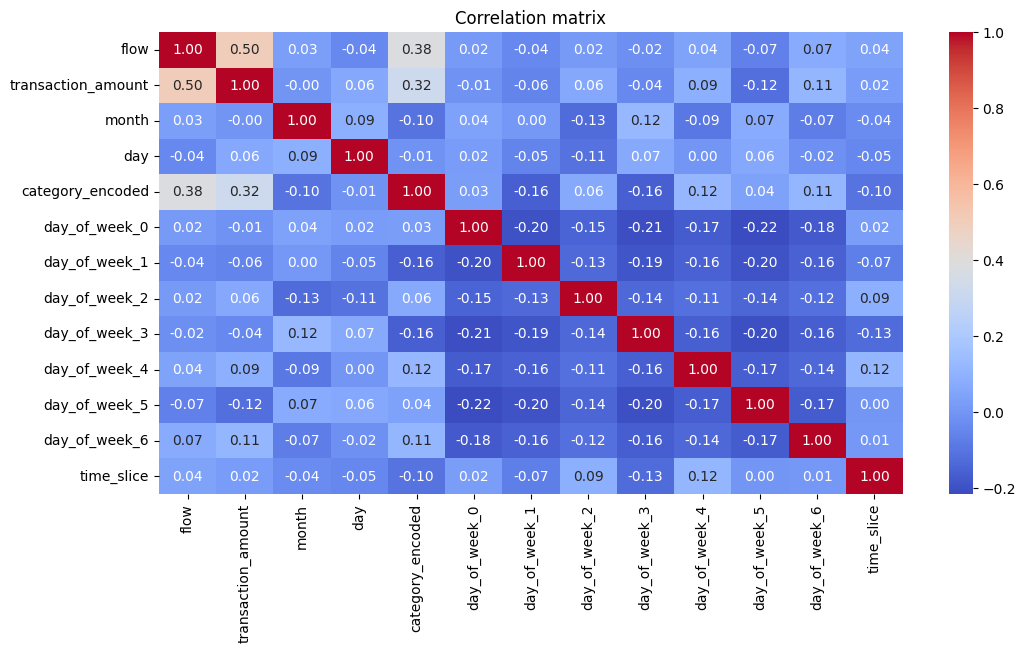

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

corr = fin_df_filtered.corr(numeric_only=True)
plt.figure(figsize = (12,6))
sns.heatmap(corr,annot = True, fmt ='.2f', cmap = 'coolwarm')
plt.title('Correlation matrix')
plt.show()

`time_slice` shows a slight correlation of -0.10 with `category_encoded`, which is 
still quite low. Whether this feature adds meaningful signal will be validated 
through model performance comparison rather than correlation alone.

In [60]:
le_reindex = LabelEncoder()
fin_df_filtered['category_encoded'] = le_reindex.fit_transform(fin_df_filtered['category_encoded'])

print(fin_df_filtered['category_encoded'].value_counts())

def create_dataset(df, signed=False, time_encoding='ordinal'):
    d = df.copy()
    if signed:
        d['transaction_amount'] = d.apply(
            lambda row: -row['transaction_amount'] if row['flow'] == 0 else row['transaction_amount'],
            axis=1
        )
        d.drop(columns=['flow'], inplace=True)
    if time_encoding == 'onehot':
        d = pd.get_dummies(d, columns=['time_slice'], dtype=int)
    return d

df_flow_ordinal   = create_dataset(fin_df_filtered, signed=False, time_encoding='ordinal')
df_signed_ordinal = create_dataset(fin_df_filtered, signed=True, time_encoding='ordinal')
df_flow_onehot    = create_dataset(fin_df_filtered, signed=False, time_encoding='onehot')
df_signed_onehot  = create_dataset(fin_df_filtered, signed=True, time_encoding='onehot')

df_flow_ordinal    = create_dataset(fin_df_filtered, signed=False, time_encoding='ordinal')
df_signed_ordinal  = create_dataset(fin_df_filtered, signed=True, time_encoding='ordinal')
df_flow_onehot     = create_dataset(fin_df_filtered, signed=False, time_encoding='onehot')
df_signed_onehot   = create_dataset(fin_df_filtered, signed=True, time_encoding='onehot')

category_encoded
0    114
2     50
4     26
1     12
3     12
Name: count, dtype: int64


In [61]:
le_reindex = LabelEncoder()
#fin_df_filtered.drop(columns=['time_slice'], inplace=True)
print(fin_df_filtered.columns)
fin_df_filtered['category_encoded'] = le_reindex.fit_transform(fin_df_filtered['category_encoded'])

print(fin_df_filtered['category_encoded'].value_counts())

def create_dataset(df, signed=False, time_encoding='ordinal'):
    d = df.copy()
    if signed:
        d['transaction_amount'] = d.apply(
            lambda row: -row['transaction_amount'] if row['flow'] == 0 else row['transaction_amount'],
            axis=1
        )
        d.drop(columns=['flow'], inplace=True)
    return d

df_flow_ordinal   = create_dataset(fin_df_filtered, signed=False, time_encoding='ordinal')
df_signed_ordinal = create_dataset(fin_df_filtered, signed=True, time_encoding='ordinal')
df_flow_onehot    = create_dataset(fin_df_filtered, signed=False, time_encoding='onehot')
df_signed_onehot  = create_dataset(fin_df_filtered, signed=True, time_encoding='onehot')

df_flow_ordinal    = create_dataset(fin_df_filtered, signed=False, time_encoding='ordinal')
df_signed_ordinal  = create_dataset(fin_df_filtered, signed=True, time_encoding='ordinal')
df_flow_onehot     = create_dataset(fin_df_filtered, signed=False, time_encoding='onehot')
df_signed_onehot   = create_dataset(fin_df_filtered, signed=True, time_encoding='onehot')

Index(['flow', 'transaction_amount', 'month', 'day', 'category_encoded',
       'day_of_week_0', 'day_of_week_1', 'day_of_week_2', 'day_of_week_3',
       'day_of_week_4', 'day_of_week_5', 'day_of_week_6', 'time_slice'],
      dtype='str')
category_encoded
0    114
2     50
4     26
1     12
3     12
Name: count, dtype: int64


In [62]:
datasets = {
    'df_flow_ordinal': df_flow_ordinal,
    'df_signed_ordinal': df_signed_ordinal,
    'df_flow_onehot': df_flow_onehot,
    'df_signed_onehot': df_signed_onehot
}

for name, df in datasets.items():
    print(f"\n--- {name} | Shape: {df.shape} ---")
    display(df.head(2))


--- df_flow_ordinal | Shape: (214, 13) ---


,flow,transaction_amount,month,day,category_encoded,day_of_week_0,day_of_week_1,day_of_week_2,day_of_week_3,day_of_week_4,day_of_week_5,day_of_week_6,time_slice
1,0,85,1,1,0,0,0,0,0,1,0,0,2
2,1,500,1,3,2,0,0,0,0,0,0,1,2



--- df_signed_ordinal | Shape: (214, 12) ---


,transaction_amount,month,day,category_encoded,day_of_week_0,day_of_week_1,day_of_week_2,day_of_week_3,day_of_week_4,day_of_week_5,day_of_week_6,time_slice
1,-85,1,1,0,0,0,0,0,1,0,0,2
2,500,1,3,2,0,0,0,0,0,0,1,2



--- df_flow_onehot | Shape: (214, 13) ---


,flow,transaction_amount,month,day,category_encoded,day_of_week_0,day_of_week_1,day_of_week_2,day_of_week_3,day_of_week_4,day_of_week_5,day_of_week_6,time_slice
1,0,85,1,1,0,0,0,0,0,1,0,0,2
2,1,500,1,3,2,0,0,0,0,0,0,1,2



--- df_signed_onehot | Shape: (214, 12) ---


,transaction_amount,month,day,category_encoded,day_of_week_0,day_of_week_1,day_of_week_2,day_of_week_3,day_of_week_4,day_of_week_5,day_of_week_6,time_slice
1,-85,1,1,0,0,0,0,0,1,0,0,2
2,500,1,3,2,0,0,0,0,0,0,1,2


In [63]:
target = 'category_encoded'
le_reindex = LabelEncoder()
fin_df_filtered['category_encoded'] = le_reindex.fit_transform(fin_df_filtered['category_encoded'])

print(fin_df_filtered['category_encoded'].value_counts())

def get_xy(df):
    X = df.drop(columns = [target])
    y = df[target]

    return X,y

X1, y1 = get_xy(df_flow_ordinal)
X2, y2 = get_xy(df_signed_ordinal)
X3, y3 = get_xy(df_flow_onehot)
X4, y4 = get_xy(df_signed_onehot)

# Verify
print("X1:", X1.shape, "y1:", y1.shape)
print("X2:", X2.shape, "y2:", y2.shape)
print("X3:", X3.shape, "y3:", y3.shape)
print("X4:", X4.shape, "y4:", y4.shape)

category_encoded
0    114
2     50
4     26
1     12
3     12
Name: count, dtype: int64
X1: (214, 12) y1: (214,)
X2: (214, 11) y2: (214,)
X3: (214, 12) y3: (214,)
X4: (214, 11) y4: (214,)


## 4. Model Building
Training and Evaluating Multiple Classification Models

## Ablation Study

To make informed feature engineering decisions, we maintain 4 versions of the dataset
and train each model on all 4. This allows us to measure the actual impact of each
design choice rather than relying on assumptions.

**Two decisions being tested:**

1. **Flow encoding** — does keeping `flow` as a separate binary feature perform better
   than encoding it directly into `transaction_amount` as a signed value (negative for expense,
   positive for income)?

2. **Time of day encoding** — does Ordinal encoding of `time_slice` perform better or worse
   than One Hot encoding across different model types?

**The 4 datasets:**

| Dataset | Flow | Time Encoding |
|---------|------|---------------|
| df_flow_ordinal | Separate binary column | Ordinal |
| df_signed_ordinal | Signed transaction amount | Ordinal |
| df_flow_onehot | Separate binary column | One Hot |
| df_signed_onehot | Signed transaction amount | One Hot |

The model that performs best across the most datasets will inform our final
feature engineering decisions for the production pipeline in Stage 3.

In [64]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report,confusion_matrix, ConfusionMatrixDisplay

In [65]:
models = [
    DecisionTreeClassifier(random_state=42),
    RandomForestClassifier(random_state=42),
    LogisticRegression(random_state=42, max_iter=1000),
    XGBClassifier(random_state=42)
]

datasets = {
    'flow_ordinal': (X1, y1),
    'signed_ordinal': (X2, y2),
    'flow_onehot': (X3, y3),
    'signed_onehot': (X4, y4)
}

results = []

for df_name, (X, y) in datasets.items():
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    models = [
        DecisionTreeClassifier(random_state=42),
        RandomForestClassifier(random_state=42),
        LogisticRegression(random_state=42, max_iter=1000),
        XGBClassifier(random_state=42)
    ]

    for model in models:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        results.append({
            'dataset': df_name,
            'model': model.__class__.__name__,
            'accuracy': round(accuracy_score(y_test, y_pred)* 100,2)
        })

results_df = pd.DataFrame(results)

def highlight_row(row, df, col):
    if row[col] == df[col].max():
        return ['background-color: green; color: white'] * len(row)
    elif row[col] == df[col].min():
        return ['background-color: #cc3300; color: white'] * len(row)
    return [''] * len(row)

results_df.style.apply(lambda row: highlight_row(row, results_df, 'accuracy'), axis=1)

d:\Workspace\Projects\AI_ML\behavioural-finance-analyser\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
d:\Workspace\Projects\AI_ML\behavioural-finance-analyser\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:

,dataset,model,accuracy
0,flow_ordinal,DecisionTreeClassifier,72.090000
1,flow_ordinal,RandomForestClassifier,79.070000
2,flow_ordinal,LogisticRegression,72.090000
3,flow_ordinal,XGBClassifier,79.070000
4,signed_ordinal,DecisionTreeClassifier,72.090000
5,signed_ordinal,RandomForestClassifier,72.090000
6,signed_ordinal,LogisticRegression,62.790000
7,signed_ordinal,XGBClassifier,81.400000
8,flow_onehot,DecisionTreeClassifier,72.090000
9,flow_onehot,RandomForestClassifier,79.070000


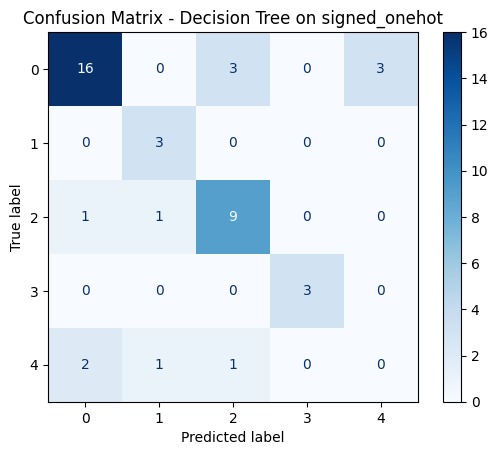

              precision    recall  f1-score   support

           0       0.84      0.73      0.78        22
           1       0.60      1.00      0.75         3
           2       0.69      0.82      0.75        11
           3       1.00      1.00      1.00         3
           4       0.00      0.00      0.00         4

    accuracy                           0.72        43
   macro avg       0.63      0.71      0.66        43
weighted avg       0.72      0.72      0.71        43



In [66]:
X_train, X_test, y_train, y_test = train_test_split(X4, y4, test_size=0.2, random_state=42)

best_model = DecisionTreeClassifier(random_state=42)
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap = 'Blues')
plt.title('Confusion Matrix - Decision Tree on signed_onehot')
plt.show()

print(classification_report(y_test, y_pred))

In [67]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

kfold_results = []
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for df_name, (X, y) in zip(
    ['flow_ordinal', 'signed_ordinal', 'flow_onehot', 'signed_onehot'],
    [(X1, y1), (X2, y2), (X3, y3), (X4, y4)]
):
    models = [
        DecisionTreeClassifier(random_state=42),
        RandomForestClassifier(random_state=42),
        LogisticRegression(random_state=42, max_iter=1000),
        XGBClassifier(random_state=42)
    ]
    for model in models:
        scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy')
        kfold_results.append({
            'dataset': df_name,
            'model': model.__class__.__name__,
            'mean_accuracy': scores.mean(),
            'std': scores.std()
        })

kfold_df = pd.DataFrame(kfold_results)

(kfold_df.style
    .apply(lambda row: highlight_row(row, kfold_df, 'mean_accuracy'), axis=1)
    .format({'mean_accuracy': '{:.2%}', 'std': '{:.4f}'})
    .set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#2c2c2c'), ('color', 'white'), ('font-size', '13px'), ('padding', '8px')]},
        {'selector': 'td', 'props': [('padding', '8px'), ('font-size', '12px')]},
        {'selector': 'tr', 'props': [('border-bottom', '1px solid #ddd')]},
    ])
    .set_caption('K-Fold Cross Validation Results')
)

d:\Workspace\Projects\AI_ML\behavioural-finance-analyser\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
d:\Workspace\Projects\AI_ML\behavioural-finance-analyser\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:

,dataset,model,mean_accuracy,std
0,flow_ordinal,DecisionTreeClassifier,68.72%,0.0690
1,flow_ordinal,RandomForestClassifier,74.76%,0.0374
2,flow_ordinal,LogisticRegression,70.55%,0.0686
3,flow_ordinal,XGBClassifier,75.25%,0.0710
4,signed_ordinal,DecisionTreeClassifier,66.82%,0.0784
5,signed_ordinal,RandomForestClassifier,69.16%,0.0270
6,signed_ordinal,LogisticRegression,61.21%,0.0603
7,signed_ordinal,XGBClassifier,74.31%,0.0566
8,flow_onehot,DecisionTreeClassifier,68.72%,0.0690
9,flow_onehot,RandomForestClassifier,74.76%,0.0374


### Time Slice Feature Impact

Adding `time_slice` (Morning, Afternoon, Evening, Night) improved overall accuracy
from 72% to 77% on the single split evaluation. Most notably, recall for Food (class 0)
improved from 73% to 82%, which makes intuitive sense — eating patterns follow
predictable time of day behaviour. K-Fold results confirmed a marginal but consistent
improvement. `time_slice` is retained in the final feature set.

### Evaluation Metric - Why Accuracy Alone is Insufficient

The dataset is class imbalanced, Food dominates with 114 samples while Salary 
has only 12. In such cases, accuracy can be misleading as a model predicting the 
majority class every time would still score reasonably high.

**Weighted F1 Score (0.75)** is a more honest metric here as it accounts for class 
imbalance by weighting each class by its support. **Macro F1 (0.67)** is lower, 
revealing that the model struggles with minority classes, particularly Salary (class 4) 
which has 0% recall across all experiments.

Both accuracy and weighted F1 are reported together for a complete picture of model performance.

In [68]:
print(fin_df_filtered.columns.tolist())

['flow', 'transaction_amount', 'month', 'day', 'category_encoded', 'day_of_week_0', 'day_of_week_1', 'day_of_week_2', 'day_of_week_3', 'day_of_week_4', 'day_of_week_5', 'day_of_week_6', 'time_slice']


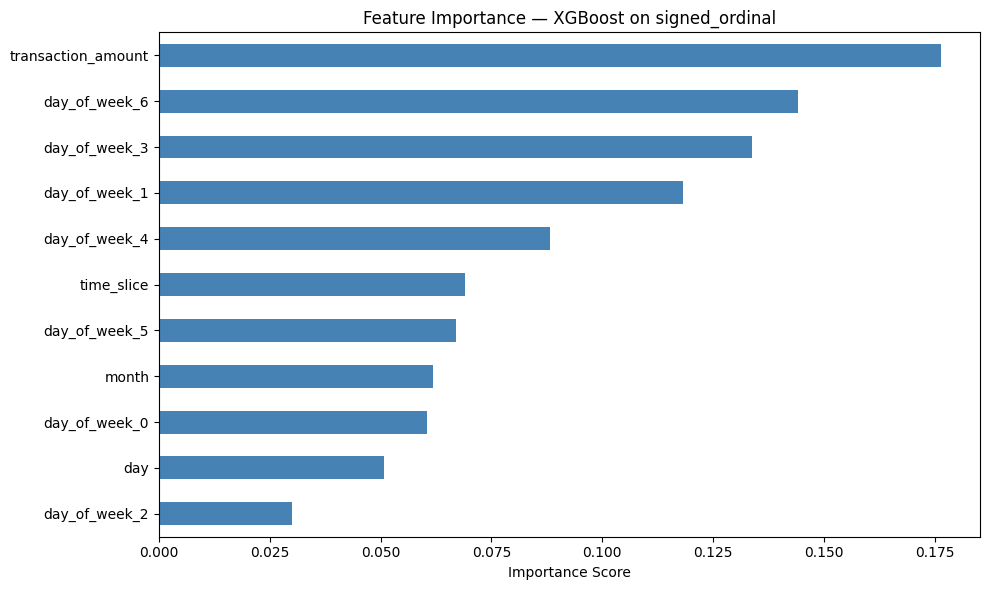

In [69]:
import matplotlib.pyplot as plt

# Train best model
X_train, X_test, y_train, y_test = train_test_split(X2, y2, test_size=0.2, random_state=42)

best_model = XGBClassifier(random_state=42)
best_model.fit(X_train, y_train)

# Feature importance
importance = pd.Series(best_model.feature_importances_, index=X2.columns)
importance = importance.sort_values(ascending=True)

importance.plot(kind='barh', figsize=(10, 6), color='steelblue')
plt.title('Feature Importance — XGBoost on signed_ordinal')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

In [70]:
import joblib

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
le.fit(fin_df['Category'])
joblib.dump(le, '../models/label_encoder.pkl')

joblib.dump(best_model, '../models/best_model_xgb.pkl')
joblib.dump(le_reindex, '../models/label_encoder.pkl')
df_signed_ordinal.to_csv('../data/processed/df_signed_ordinal.csv', index=False)
print("All saved successfully")

All saved successfully


XGBoost on the signed_ordinal dataset was chosen based on K-Fold cross-validation (75.25%), which is more reliable than single-split accuracy. In this dataset, flow is encoded directly into transaction_amount as a sign (negative for expenses, positive for income). time_slice was excluded as it did not consistently improve performance across folds.

In [71]:
print(best_model.feature_names_in_)

['transaction_amount' 'month' 'day' 'day_of_week_0' 'day_of_week_1'
 'day_of_week_2' 'day_of_week_3' 'day_of_week_4' 'day_of_week_5'
 'day_of_week_6' 'time_slice']


In [72]:
le_reindex.classes_

array([0, 1, 2, 3, 4])

In [73]:
fin_df_filtered[['Category', 'category_encoded']].drop_duplicates().sort_values('category_encoded')

KeyError: "['Category'] not in index"